In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix , precision_score , accuracy_score , recall_score , f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [2]:
loan_data = pd.read_csv("loan_approval_data.csv")

In [3]:
loan_data.head()
loan_data.isnull().sum()
loan_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

# Handling Missing Values

In [4]:
# Selecting columns with numerical data to impute it with mean
numerical_cols = loan_data.select_dtypes(include = "number").columns

numerical_imputer = SimpleImputer(strategy = "mean")
loan_data[numerical_cols] = numerical_imputer.fit_transform(loan_data[numerical_cols])

# Selecting columns with categorical data to impute it with mode(most_frequent)
categorical_cols = loan_data.select_dtypes(include = "object").columns

categorical_imputer = SimpleImputer(strategy = "most_frequent")
loan_data[categorical_cols] = categorical_imputer.fit_transform(loan_data[categorical_cols])

In [5]:
loan_data.head(10)

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.000000,Salaried,51.0,Married,0.0,637.0,4.0,0.530000,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.000000,Salaried,46.0,Married,3.0,621.0,2.0,0.300000,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.000000,Salaried,25.0,Single,2.0,674.0,4.0,0.200000,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.000000,Salaried,40.0,Married,2.0,579.0,3.0,0.310000,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.000000,Self-employed,31.0,Single,2.0,721.0,1.0,0.290000,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes
5,6.0,8265.0,4831.000000,Salaried,53.0,Single,1.0,602.0,1.0,0.560000,19522.0,2911.0,9798.0,36.0,Home,Semiurban,Graduate,Male,Unemployed,No
6,7.0,18850.0,2768.000000,Salaried,58.0,Married,0.0,687.0,0.0,0.480000,14635.0,8991.0,26143.0,24.0,Home,Rural,Graduate,Male,Private,No
7,8.0,6426.0,3186.000000,Salaried,47.0,Married,2.0,636.0,4.0,0.347263,671.0,11572.0,33747.0,84.0,Personal,Rural,Graduate,Female,Private,No
8,9.0,16423.0,5082.455789,Salaried,54.0,Married,1.0,729.0,0.0,0.590000,777.0,43066.0,34651.0,36.0,Home,Semiurban,Graduate,Male,Private,No
9,10.0,13363.0,2599.000000,Contract,35.0,Single,3.0,726.0,1.0,0.347263,3022.0,29693.0,22182.0,60.0,Personal,Rural,Graduate,Female,Government,Yes


# EDA (Exploratory Data Analysis)

In [6]:
# Removing Applicant id 
loan_data = loan_data.drop("Applicant_ID",axis = 1)

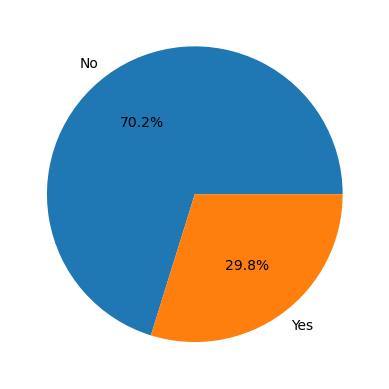

In [23]:
# How balanced are the classes

classes_count = loan_data["Loan_Approved"].value_counts()

plt.pie( classes_count ,labels = ["No","Yes"] , autopct="%1.1f%%")
plt.show()

[Text(0, 0, '722'), Text(0, 0, '278')]

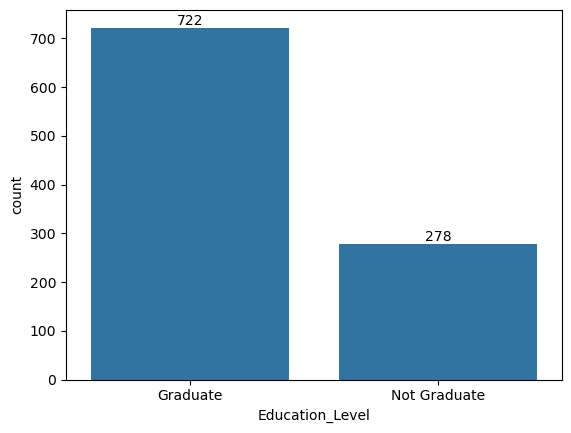

In [34]:
# Analyazing Categories 

gender_count = loan_data["Gender"].value_counts()

ax = sns.barplot(gender_count)
ax.bar_label(ax.containers[0])

education_count = loan_data["Education_Level"].value_counts()

ax = sns.barplot(education_count)
ax.bar_label(ax.containers[0])

In [26]:
gender_count

Gender
Male      621
Female    379
Name: count, dtype: int64

<Axes: xlabel='Credit_Score', ylabel='Count'>

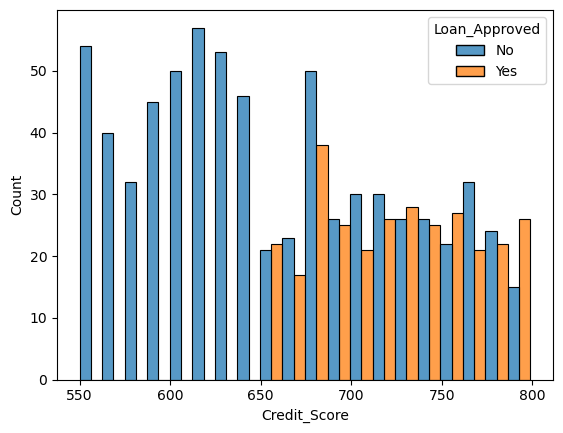

In [40]:
# Analyzing income 
# sns.histplot(
#     data = loan_data,
#     x = "Applicant_Income",
#     bins = 20,
#     hue = "Loan_Approved",
#     multiple = "dodge"
# )
# sns.histplot(
#     data = loan_data,
#     x = "Coapplicant_Income",
#     bins = 20,
#     hue = "Loan_Approved",
#     multiple = "dodge"
# )
sns.histplot(
    data = loan_data,
    x = "Credit_Score",
    bins = 20,
    hue = "Loan_Approved",
    multiple = "dodge"
)

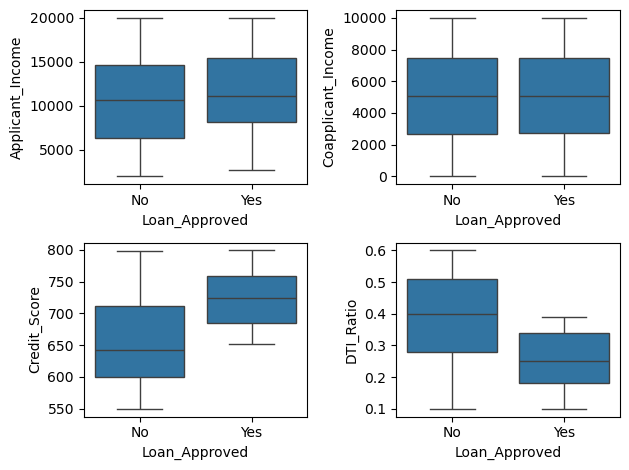

In [46]:
# Outlies - Box plot

fig , axes = plt.subplots(2,2)

sns.boxplot(ax = axes[0,0], data = loan_data , x = "Loan_Approved",y = "Applicant_Income")
sns.boxplot(ax = axes[0,1], data = loan_data , x = "Loan_Approved",y = "Coapplicant_Income")
sns.boxplot(ax = axes[1,0], data = loan_data , x = "Loan_Approved",y = "Credit_Score")
sns.boxplot(ax = axes[1,1], data = loan_data , x = "Loan_Approved",y = "DTI_Ratio")

fig.tight_layout()

# Encoding

In [61]:
# Label Encoding (Where order matters)
le = LabelEncoder()
loan_data["Education_Level"] = le.fit_transform(loan_data["Education_Level"])
loan_data["Loan_Approved"] = le.fit_transform(loan_data["Loan_Approved"])

# One Hot Encoding (Where order doesn't matters)
ohe = OneHotEncoder(drop = "first",sparse_output = False ,handle_unknown = "ignore")
ohe_columns = ["Employment_Status","Marital_Status","Loan_Purpose","Property_Area","Gender","Employer_Category"]
encoded = ohe.fit_transform(loan_data[ohe_columns])

# New DataFrame with encoded values 
encoded_df = pd.DataFrame(encoded,columns = ohe.get_feature_names_out(ohe_columns) ,index =loan_data.index)

# Removing old columns from original DataFrame and concatinating with the new encoded DataFrame
new_loan_data = pd.concat([loan_data.drop(columns = ohe_columns) , encoded_df] , axis = 1 )

In [64]:
new_loan_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved        

In [65]:
new_loan_data.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


# Correlation Heatmap

<Axes: >

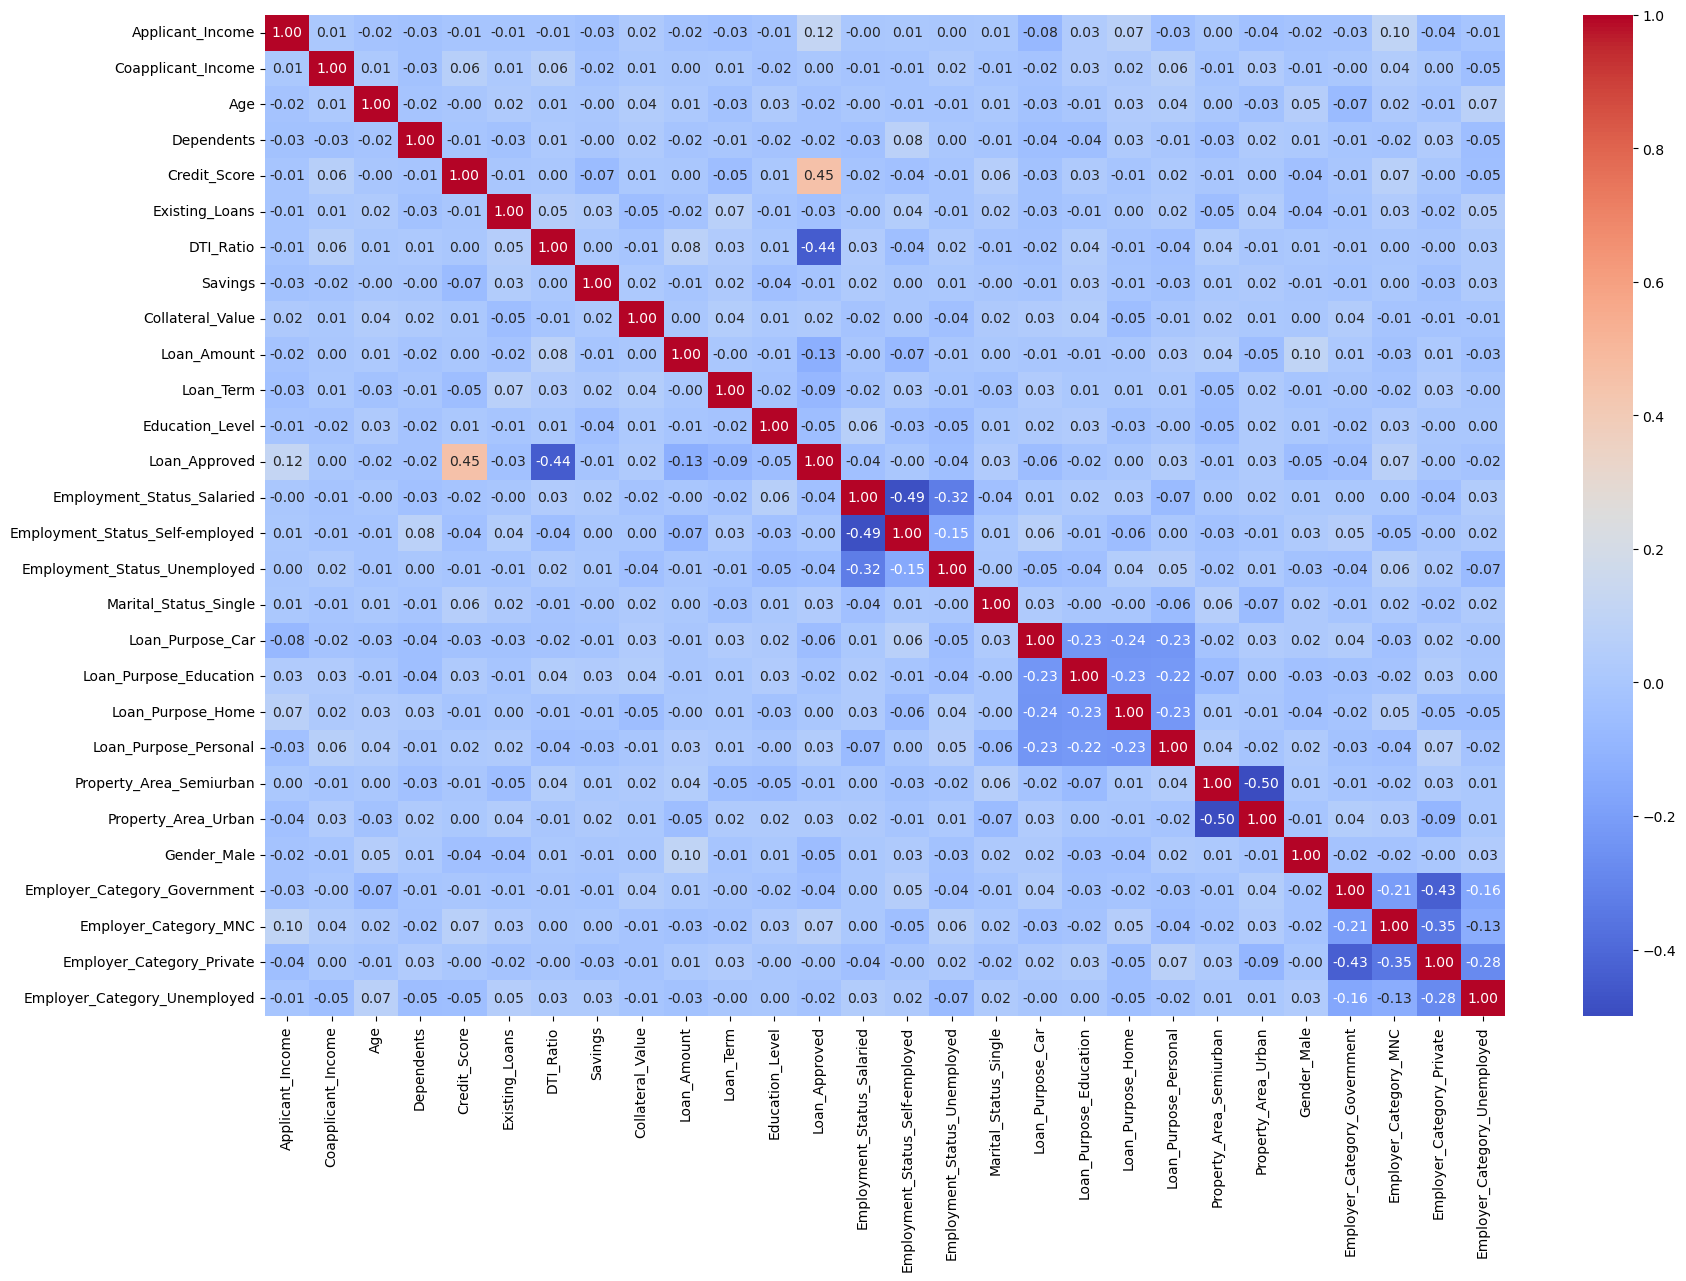

In [70]:
numerical_columns = new_loan_data.select_dtypes(include = "number")
corr_matrix = numerical_columns.corr()

plt.figure(figsize=(20,13))

sns.heatmap(
    corr_matrix,
    annot = True,
    fmt = ".2f",
    cmap = "coolwarm"
)

In [74]:
# to see correlation with loan approved 
numerical_columns.corr()["Loan_Approved"].sort_values(ascending = False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

# Feature Scaling + Train Test Split

In [98]:
X = new_loan_data.drop(columns = ["Loan_Approved"])
y = new_loan_data["Loan_Approved"]

X_train , X_test , y_train , y_test = train_test_split(
    X, y, test_size = 0.2,random_state = 42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [104]:
# Logistic Regression 

logistic_model = LogisticRegression()
logistic_model.fit(X_train_scaled,y_train)

y_pred = logistic_model.predict(X_test_scaled)

# Evaluation 
print("Logistic Regression")
print("Precision score : ", precision_score(y_test,y_pred))
print("Accuracy score : ", accuracy_score(y_test,y_pred))
print("Recall score : ", recall_score(y_test,y_pred))
print("f1 score : ", f1_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

Logistic Regression
Precision score :  0.7833333333333333
Accuracy score :  0.865
Recall score :  0.7704918032786885
f1 score :  0.7768595041322314
[[126  13]
 [ 14  47]]


In [106]:
# Knn
knn_classifier = KNeighborsClassifier(n_neighbors = 5)
knn_classifier.fit(X_train_scaled,y_train)

y_pred = knn_classifier.predict(X_test_scaled)

# Evaluation 
print("knn classifier")
print("Precision score : ", precision_score(y_test,y_pred))
print("Accuracy score : ", accuracy_score(y_test,y_pred))
print("Recall score : ", recall_score(y_test,y_pred))
print("f1 score : ", f1_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

knn classifier
Precision score :  0.6274509803921569
Accuracy score :  0.76
Recall score :  0.5245901639344263
f1 score :  0.5714285714285714
[[120  19]
 [ 29  32]]


In [118]:
# Naive Bayes
gnb_classifier = GaussianNB()
gnb_classifier.fit(X_train_scaled,y_train)

y_pred = gnb_classifier.predict(X_test_scaled)

# Evaluation 
print("Naive classifier")
print("Precision score : ", precision_score(y_test,y_pred))
print("Accuracy score : ", accuracy_score(y_test,y_pred))
print("Recall score : ", recall_score(y_test,y_pred))
print("f1 score : ", f1_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

Naive classifier
Precision score :  0.7833333333333333
Accuracy score :  0.865
Recall score :  0.7704918032786885
f1 score :  0.7768595041322314
[[126  13]
 [ 14  47]]


# Best Model on the basis of precision is Naive Bayes

# Feature Scaling

In [119]:
# Add and transform features

new_loan_data["DTI_Ratio_sq"] = new_loan_data["DTI_Ratio"] ** 2
new_loan_data["Credit_Score_sq"] = new_loan_data["Credit_Score"] ** 2


# Also we can take log of those features which have skewed data (in this their is no such feature)

X = new_loan_data.drop(columns = ["DTI_Ratio","Credit_Score","Loan_Approved"])
y = new_loan_data["Loan_Approved"]


X_train , X_test , y_train , y_test = train_test_split(
    X, y, test_size = 0.2,random_state = 42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [120]:
# Logistic Regression 

logistic_model = LogisticRegression()
logistic_model.fit(X_train_scaled,y_train)

y_pred = logistic_model.predict(X_test_scaled)

# Evaluation 
print("Logistic Regression")
print("Precision score : ", precision_score(y_test,y_pred))
print("Accuracy score : ", accuracy_score(y_test,y_pred))
print("Recall score : ", recall_score(y_test,y_pred))
print("f1 score : ", f1_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

Logistic Regression
Precision score :  0.7903225806451613
Accuracy score :  0.875
Recall score :  0.8032786885245902
f1 score :  0.7967479674796748
[[126  13]
 [ 12  49]]


In [121]:
# Knn
knn_classifier = KNeighborsClassifier(n_neighbors = 5)
knn_classifier.fit(X_train_scaled,y_train)

y_pred = knn_classifier.predict(X_test_scaled)

# Evaluation 
print("knn classifier")
print("Precision score : ", precision_score(y_test,y_pred))
print("Accuracy score : ", accuracy_score(y_test,y_pred))
print("Recall score : ", recall_score(y_test,y_pred))
print("f1 score : ", f1_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

knn classifier
Precision score :  0.62
Accuracy score :  0.755
Recall score :  0.5081967213114754
f1 score :  0.5585585585585585
[[120  19]
 [ 30  31]]


In [122]:
# Naive Bayes
gnb_classifier = GaussianNB()
gnb_classifier.fit(X_train_scaled,y_train)

y_pred = gnb_classifier.predict(X_test_scaled)

# Evaluation 
print("Naive classifier")
print("Precision score : ", precision_score(y_test,y_pred))
print("Accuracy score : ", accuracy_score(y_test,y_pred))
print("Recall score : ", recall_score(y_test,y_pred))
print("f1 score : ", f1_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

Naive classifier
Precision score :  0.7833333333333333
Accuracy score :  0.865
Recall score :  0.7704918032786885
f1 score :  0.7768595041322314
[[126  13]
 [ 14  47]]
